In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import seaborn as sns

sns.set()

# -----------------------------------
# 2) Load Dataset
# -----------------------------------
url = "https://raw.githubusercontent.com/Pankaj-Str/Complete-Python-Mastery/refs/heads/main/53%20DataSet/Mall_Customers.csv"
df = pd.read_csv(url)

print("Dataset Loaded Successfully!")
print(df.head())

# -----------------------------------
# 3) Select Features for Clustering
# -----------------------------------
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values

# Scale the data (DBSCAN is sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Dataset Loaded Successfully!
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [26]:
# Apply DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

df["Cluster"] = labels

uniquelabels = set(labels)

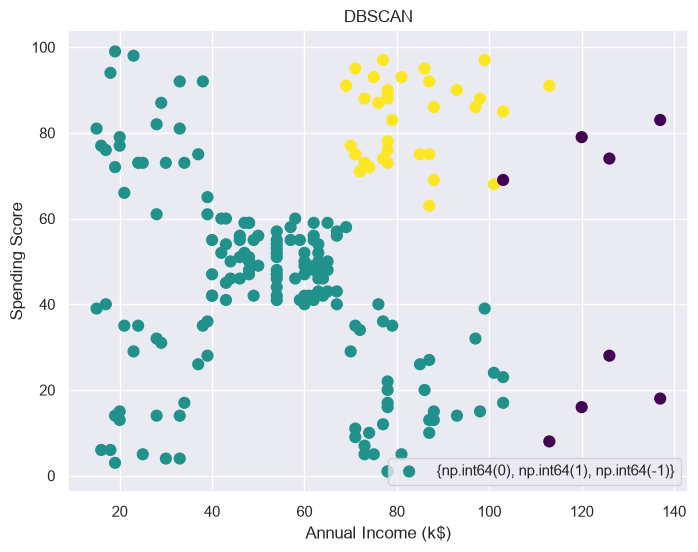

Cluster
 0    157
 1     35
-1      8
Name: count, dtype: int64


In [27]:
# Visualize DBSCAN Clusters

plt.figure(figsize=(8,6))
plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"],
            c=df["Cluster"], cmap="viridis", s=60, label=uniquelabels)

plt.title("DBSCAN")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

print(df["Cluster"].value_counts())


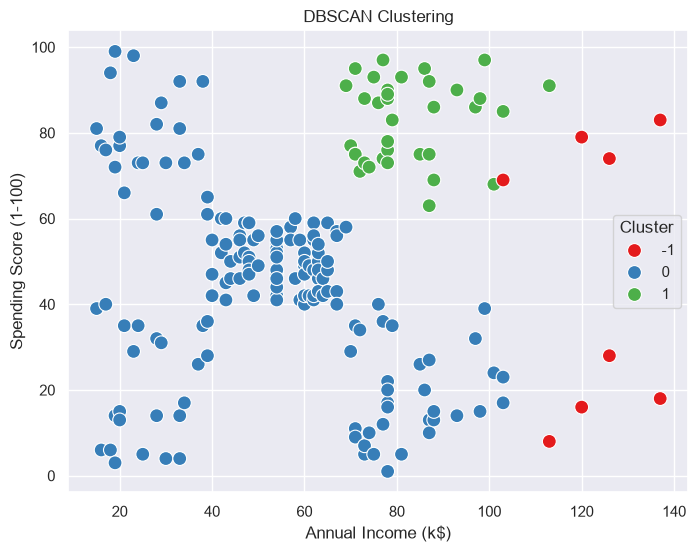

Clusters Found : 3
Cluster
 0    157
 1     35
-1      8
Name: count, dtype: int64


In [29]:
# More Accurate
# Visualize DBSCAN Clusters

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Annual Income (k$)"],
    y=df["Spending Score (1-100)"],
    hue=df["Cluster"],
    palette="Set1",
    s=100)

plt.title("DBSCAN Clustering")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")
plt.show()

print("Clusters Found :", df["Cluster"].nunique())
print(df["Cluster"].value_counts())
